# A demonstration of single-trial integrative joint modeling for decision-making using BayesFlow 2 in Google Colab

Python notebook author: Michael D. Nunez

Date: 23-July-2026
<br>
<br>

<img src="https://media.springernature.com/full/springer-static/image/art%3A10.1007%2Fs42113-023-00167-4/MediaObjects/42113_2023_167_Fig1_HTML.png" width="600">

Figure 1 from [Ghaderi-Kangavari et al., 2023](https://link.springer.com/article/10.1007/s42113-023-00167-4). A drift-diffusion model (DDM) is in the center of the figure. A DDM explains human response times (RTs) and accuracies on speeded decision-making experimental trials. A example stimulus that would might be well-described by this model is by [Grabowska et al. (2025): what direction is an arrow in the center of the screen?](https://www.sciencedirect.com/science/article/pii/S1053811925003520#fig3). There are expected relationships between different EEG waveforms (blue ang green lines in the figure) recorded from the human brain (top left in the figure) during the experiment and the cognitive parameters that describe choices and RTs. One example is the theory that the P300/CPP waveform (green line) is related to the drift rate $\delta$, the average rate of evidence accumulation to a correct choice, per trial. See the original paper by Ghaderi-Kangavari et al. (2023) for more figure details.
<br>
<br>

There are different ways to *fit* these models to data in order to get parameter estimates for each individual who performed the task. This tutorial will teach you how to fit a specific model called the "single-trial integrative model" (terminology from Ghaderi-Kangavari et al., 2023).
<br>
<br>

The following demonstration is adapted from [this github repository](https://github.com/mdnunez/single_trial_nddm_compare) associated with [this preprint by Krijgsman et al. (2026)](https://osf.io/preprints/psyarxiv/7d46a_v2). Thus, if you want to cite this demonstration in your own work, it's probably best to just cite the preprint.

#### Citation:
Krijgsman, B., Steeghs-Turchina, M., Nunez, M. D. (2026, April 29). Which model better predicts brain-behavior relationships during decision-making? A simulation-based comparison of single-trial directed and integrative drift-diffusion models. PsyArXiv. https://doi.org/10.31234/osf.io/7d46a_v2
<br>
<br>

#### Other possible citations / further reading:
Nunez, M. D., Fernandez, K., Srinivasan, R., & Vandekerckhove, J. (2024). A tutorial on fitting joint models of M/EEG and behavior to understand cognition.Behavior Research Methods. https://doi.org/10.3758/s13428-023-02331-x

Ghaderi-Kangavari, A., Rad, J. A., & Nunez, M. D. (2023). A General Integrative Neurocognitive Modeling Framework to Jointly Describe EEG and Decision-making on Single Trials. Computational Brain & Behavior, 6(3), 317–376. https://doi.org/10.1007/s42113-023-00167-4

Grabowska, A., Sondej, F., Haaf, J., Nunez, M. D., & Senderecka, M. (2025). Individual differences in neurophysiological correlates of post-response adaptation: A model-based approach. NeuroImage, 318, 121349. https://doi.org/10.1016/j.neuroimage.2025.121349


# Integrative model demonstration on Google Colab

Nothing needs to be installed on your own laptop. You only need a browser and a Google account. The model fitting procedure runs [BayesFlow 2](https://github.com/bayesflow-org/bayesflow) but used a model fitting procedure (in the repository) that was already trained on the Dutch supercomputing cluster Snellius. These models can be trained on your own laptops, but we didn't optimize the code for that.
<br>
<br>

This notebook will probably stop working on Google Colab one day because Google will update their runtime servers. It already relies on *not running Python (3.11) in the displayed python environment but in a background environment on Google's Linux machines*. If the Google Colab doesn't work for you, [check out these Docker instructions](https://github.com/mdnunez/single_trial_nddm_compare/blob/workshop_demo/workshop_steps.md). Or try to run it yourself on your own Linux machine!
<br>
<br>

This Colab notebook also uses the program uv, which I can highly recommend to manage Python environments.
<br>
<br>

**Runtime tip:** the project pins the CPU build of JAX (`jax==0.6.1`), so a GPU buys you nothing here. `Runtime → Change runtime type → CPU` is fine and connects faster.

## Step 1 — Just run this code.

You can read it if you want to, but most of it is Google Colab specific. For real research, you shouldn't do things on Google colab (e.g. it is not reproducible because Google runtimes are changed constantly)

In [ ]:
%%time

### Check what machine you got ###
import os, sys, shutil, platform
print("Notebook Python :", sys.version.split()[0], "->", sys.executable)
print("OS              :", platform.platform())
print("CPU cores       :", os.cpu_count())
free_gb = shutil.disk_usage("/").free / 1e9
print(f"Free disk       : {free_gb:.0f} GB")
print("Colab release   :", os.environ.get("COLAB_RELEASE_TAG", "(not a hosted Colab runtime)"))
print('============================')

### Install uv ###
# uv is a single fast program that manages Python versions, virtual environments and packages.
# uv is being installed on the linux machine, that is why the "!" is at the beginning
!pip install -q uv
!uv --version
print('============================')

### Colab-specifc gotcha ###
# Colab pre-sets a constraints-file environment variable that points at a path inside its own backend container.
# That path is not always present, and `uv` willstop with:
# `error: File not found: /backend-container/containers/requirements.constraints`
# Clearing those variables from the notebook process is enough — every `!` command inherits the environment from this kernel.
for var in ("PIP_CONSTRAINT", "UV_CONSTRAINT", "UV_BUILD_CONSTRAINT"):
  old = os.environ.pop(var, None)
  if old:
    print(f"unset {var} (was {old})")

# Make sure matplotlib never tries to open a window inside a headless subprocess.
os.environ["MPLBACKEND"] = "Agg"
print("environment ready")
print('============================')

### Get the repository ###
from pathlib import Path

REPO_URL = "https://github.com/mdnunez/single_trial_nddm_compare.git"
BRANCH = "workshop_demo"


def find_project():
  # Locate the repo whether we are on hosted Colab or a local runtime.
  candidates = [
      Path.cwd(),
      Path.cwd() / "single_trial_nddm_compare",
      Path("/content/single_trial_nddm_compare"),
      ]
  for c in candidates:
    if (c / "pyproject.toml").exists() and (c / "scripts").exists():
      return c.resolve()
  return None


PROJECT = find_project()
if PROJECT is None:
  base = "/content" if Path("/content").is_dir() else str(Path.cwd())
  !cd {base} && git clone --branch {BRANCH} --single-branch --depth 1 {REPO_URL}
  PROJECT = find_project()

print("Project root:", PROJECT)
%cd {PROJECT}
print('============================')

## Step 2: Build the Python environment

This is code is specific for the [uv program](https://docs.astral.sh/uv/). You can just run this for now, but it is worthwhile learning about Python environments, if you actually want to run code like this yourself (or really any Python code) on your own machines.
<br>
<br>
Expect a few minutes: TensorFlow, JAX and BayesFlow are large downloads.

In [ ]:
%%time

### Install Python 3.11 ###
# This fetches a standalone CPython 3.11 build — this is the part Colab cannot give you on its own.
!uv python install 3.11
print('============================')

### Install Python 3.11 ###
# This creates `.venv`and installs the *exact* package versions recorded in `uv.lock`
!uv sync --locked
print('============================')

### Proof that the subprocess really is Python 3.11 ###
# The notebook kernel and the project environment are two different Pythons.
# Note the `executable` path below — it points inside `.venv`, not at Colab's Python.
check = (
    "import sys, bayesflow, keras, jax, numpy;"
    "print('python     ', sys.version.split()[0]); "
    "print('executable ', sys.executable); "
    "print('bayesflow  ', bayesflow.__version__); "
    "print('keras      ', keras.__version__, keras.backend.backend()); "
    "print('jax        ', jax.__version__); "
    "print('numpy      ', numpy.__version__)"
    )
!KERAS_BACKEND=jax uv run python -c "{check}"
print('============================')

## Step 3: "Train" the model with BayesFlow 2

Because the trained checkpoint is already in the github repository (as I said before, it was trained on a Dutch supercomputing cluster), the first script **loads** the model instead of training it. It still simulates 10,000 validation datasets for the diagnostic plots, so give it a few minutes.


In [ ]:
%%time
!uv run scripts/integrative_ddm_train.py
print('============================')

## Step 4: Learn further about what you did

### Step 4.1: Inspecting the integrative model

Find the `integrative_model/simulation.py` file in the [github repository](https://github.com/mdnunez/single_trial_nddm_compare/tree/workshop_demo) and look at how simple the model simulation is (relatively). The `simulate_trial()` definition is how you simulate one trial of the integrative model.

Test questions:
  
* Which function draws parameter values from the "prior" distribution?
* Which function simulates multiple experimental trials?
* Which function is basically just a wrapper of another for BayesFlow?
<br>
<br>

### Step 4.2: Understanding of training the model using BayesFlow 2

Find the `integrative_model/workflow.py` file in the [github repository](https://github.com/mdnunez/single_trial_nddm_compare/tree/workshop_demo). This file contains the information / commands for the [BayesFlow 2](https://arxiv.org/abs/2602.07098) package. We kept a lot of defaults / recommendations for training the integrative model.

Test questions:

* What inference network did we use?
* What summary network did we use?
* What is the difference between the inference and summary networks?
* What is the point of the adapter object?
* Did we use a fixed number of trials to train the model or a variable number of trials?

Harder questions:

* Can we train the model better?
* Can we train it faster?
<br>
<br>

### Step 4.3: Evaluating model training

Run the code below to look in your new `integrative_model/Figures` folder.

Test questions:

* Did the network training converge? How do you know it did?
* What is the difference between the simulation and validation plots?

### `Figures` — 6 figure(s)

**loss_plot_seed_12_150epochs.png**

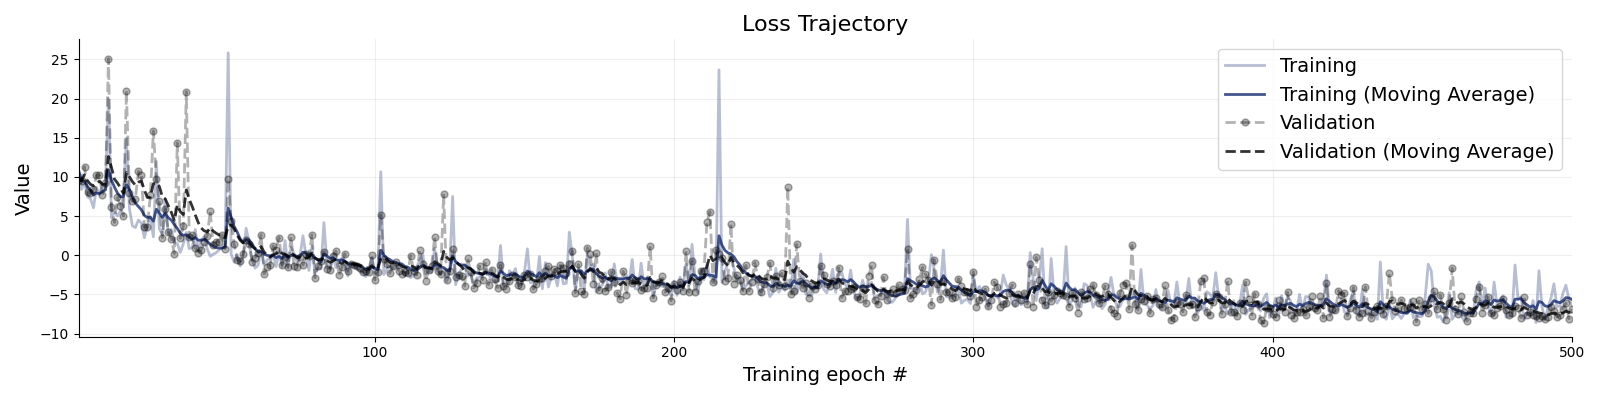

**loss_with_val_improved_seed_12_150epochs.png**

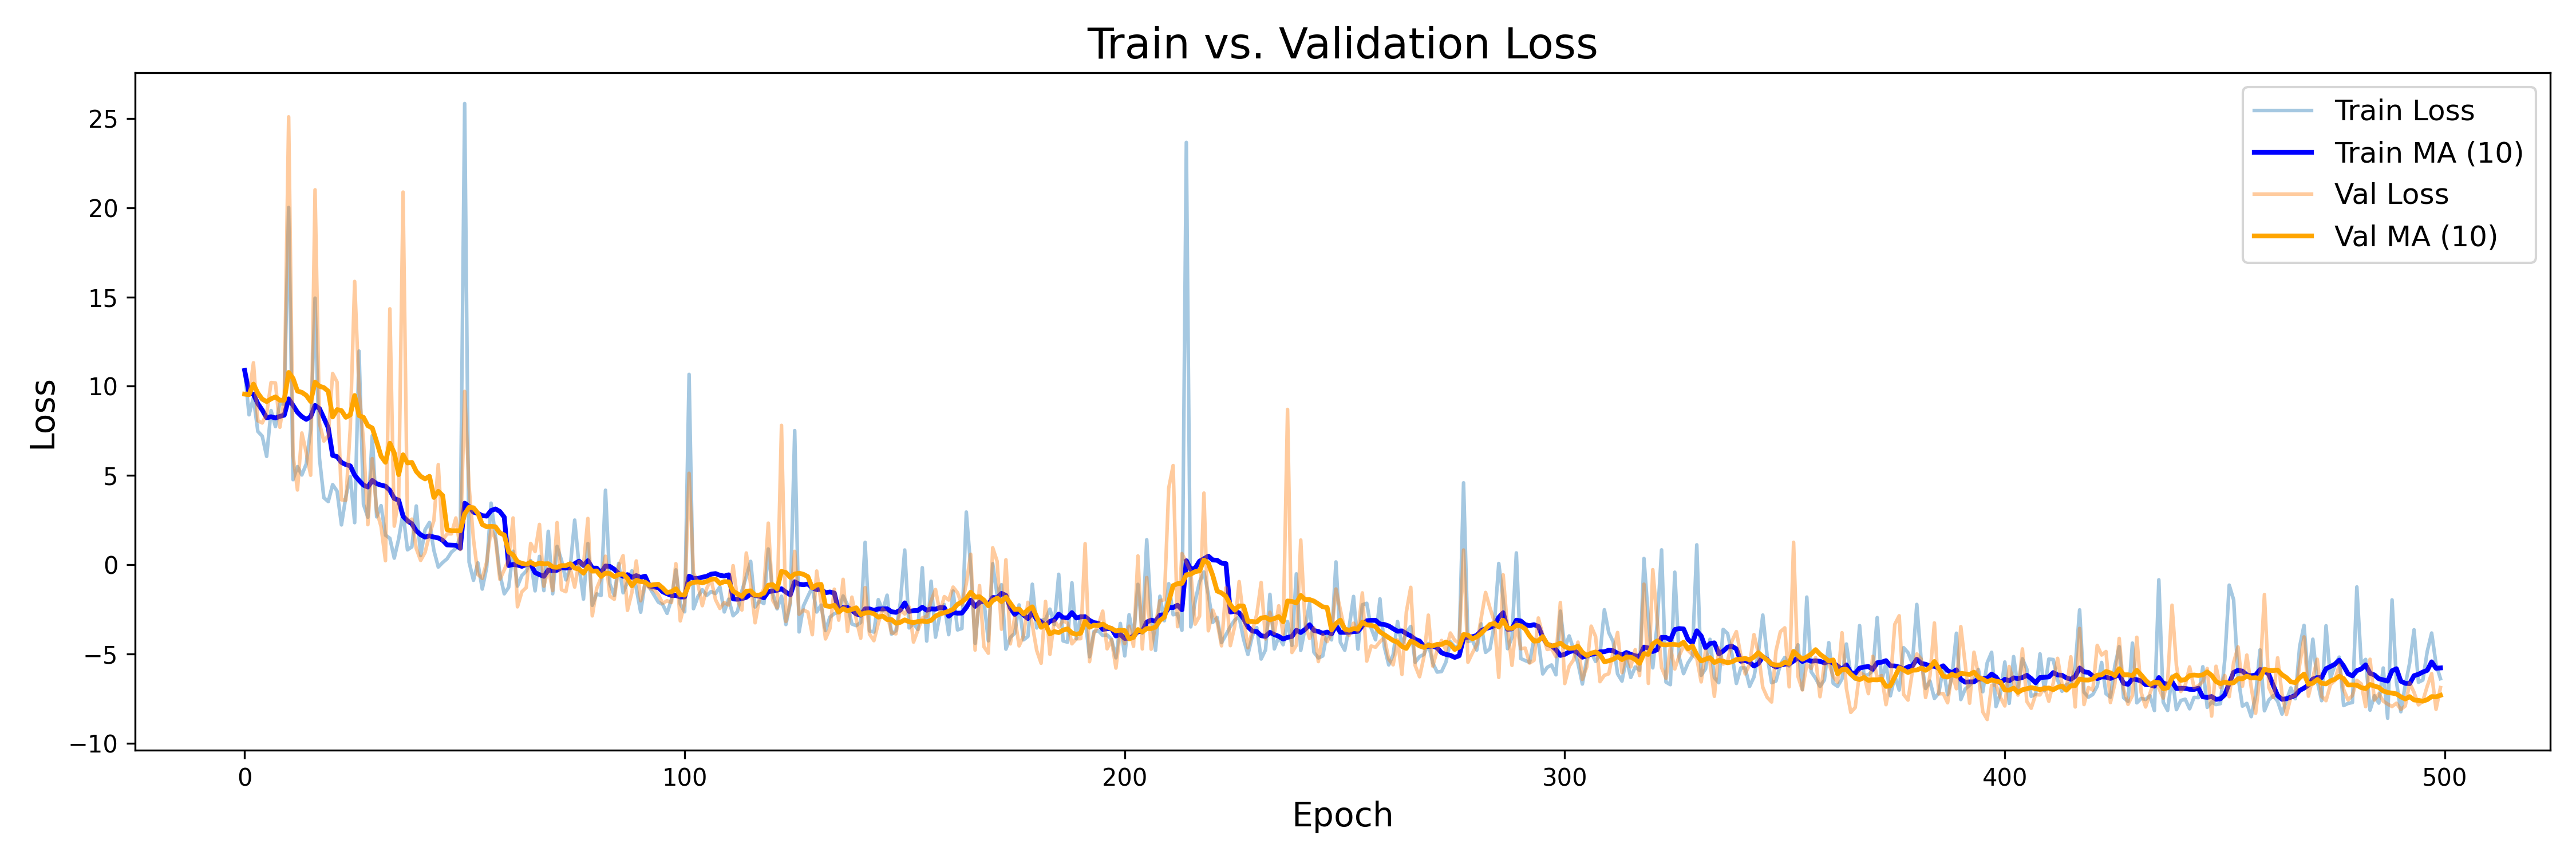

**sim_P300_distribution.png**

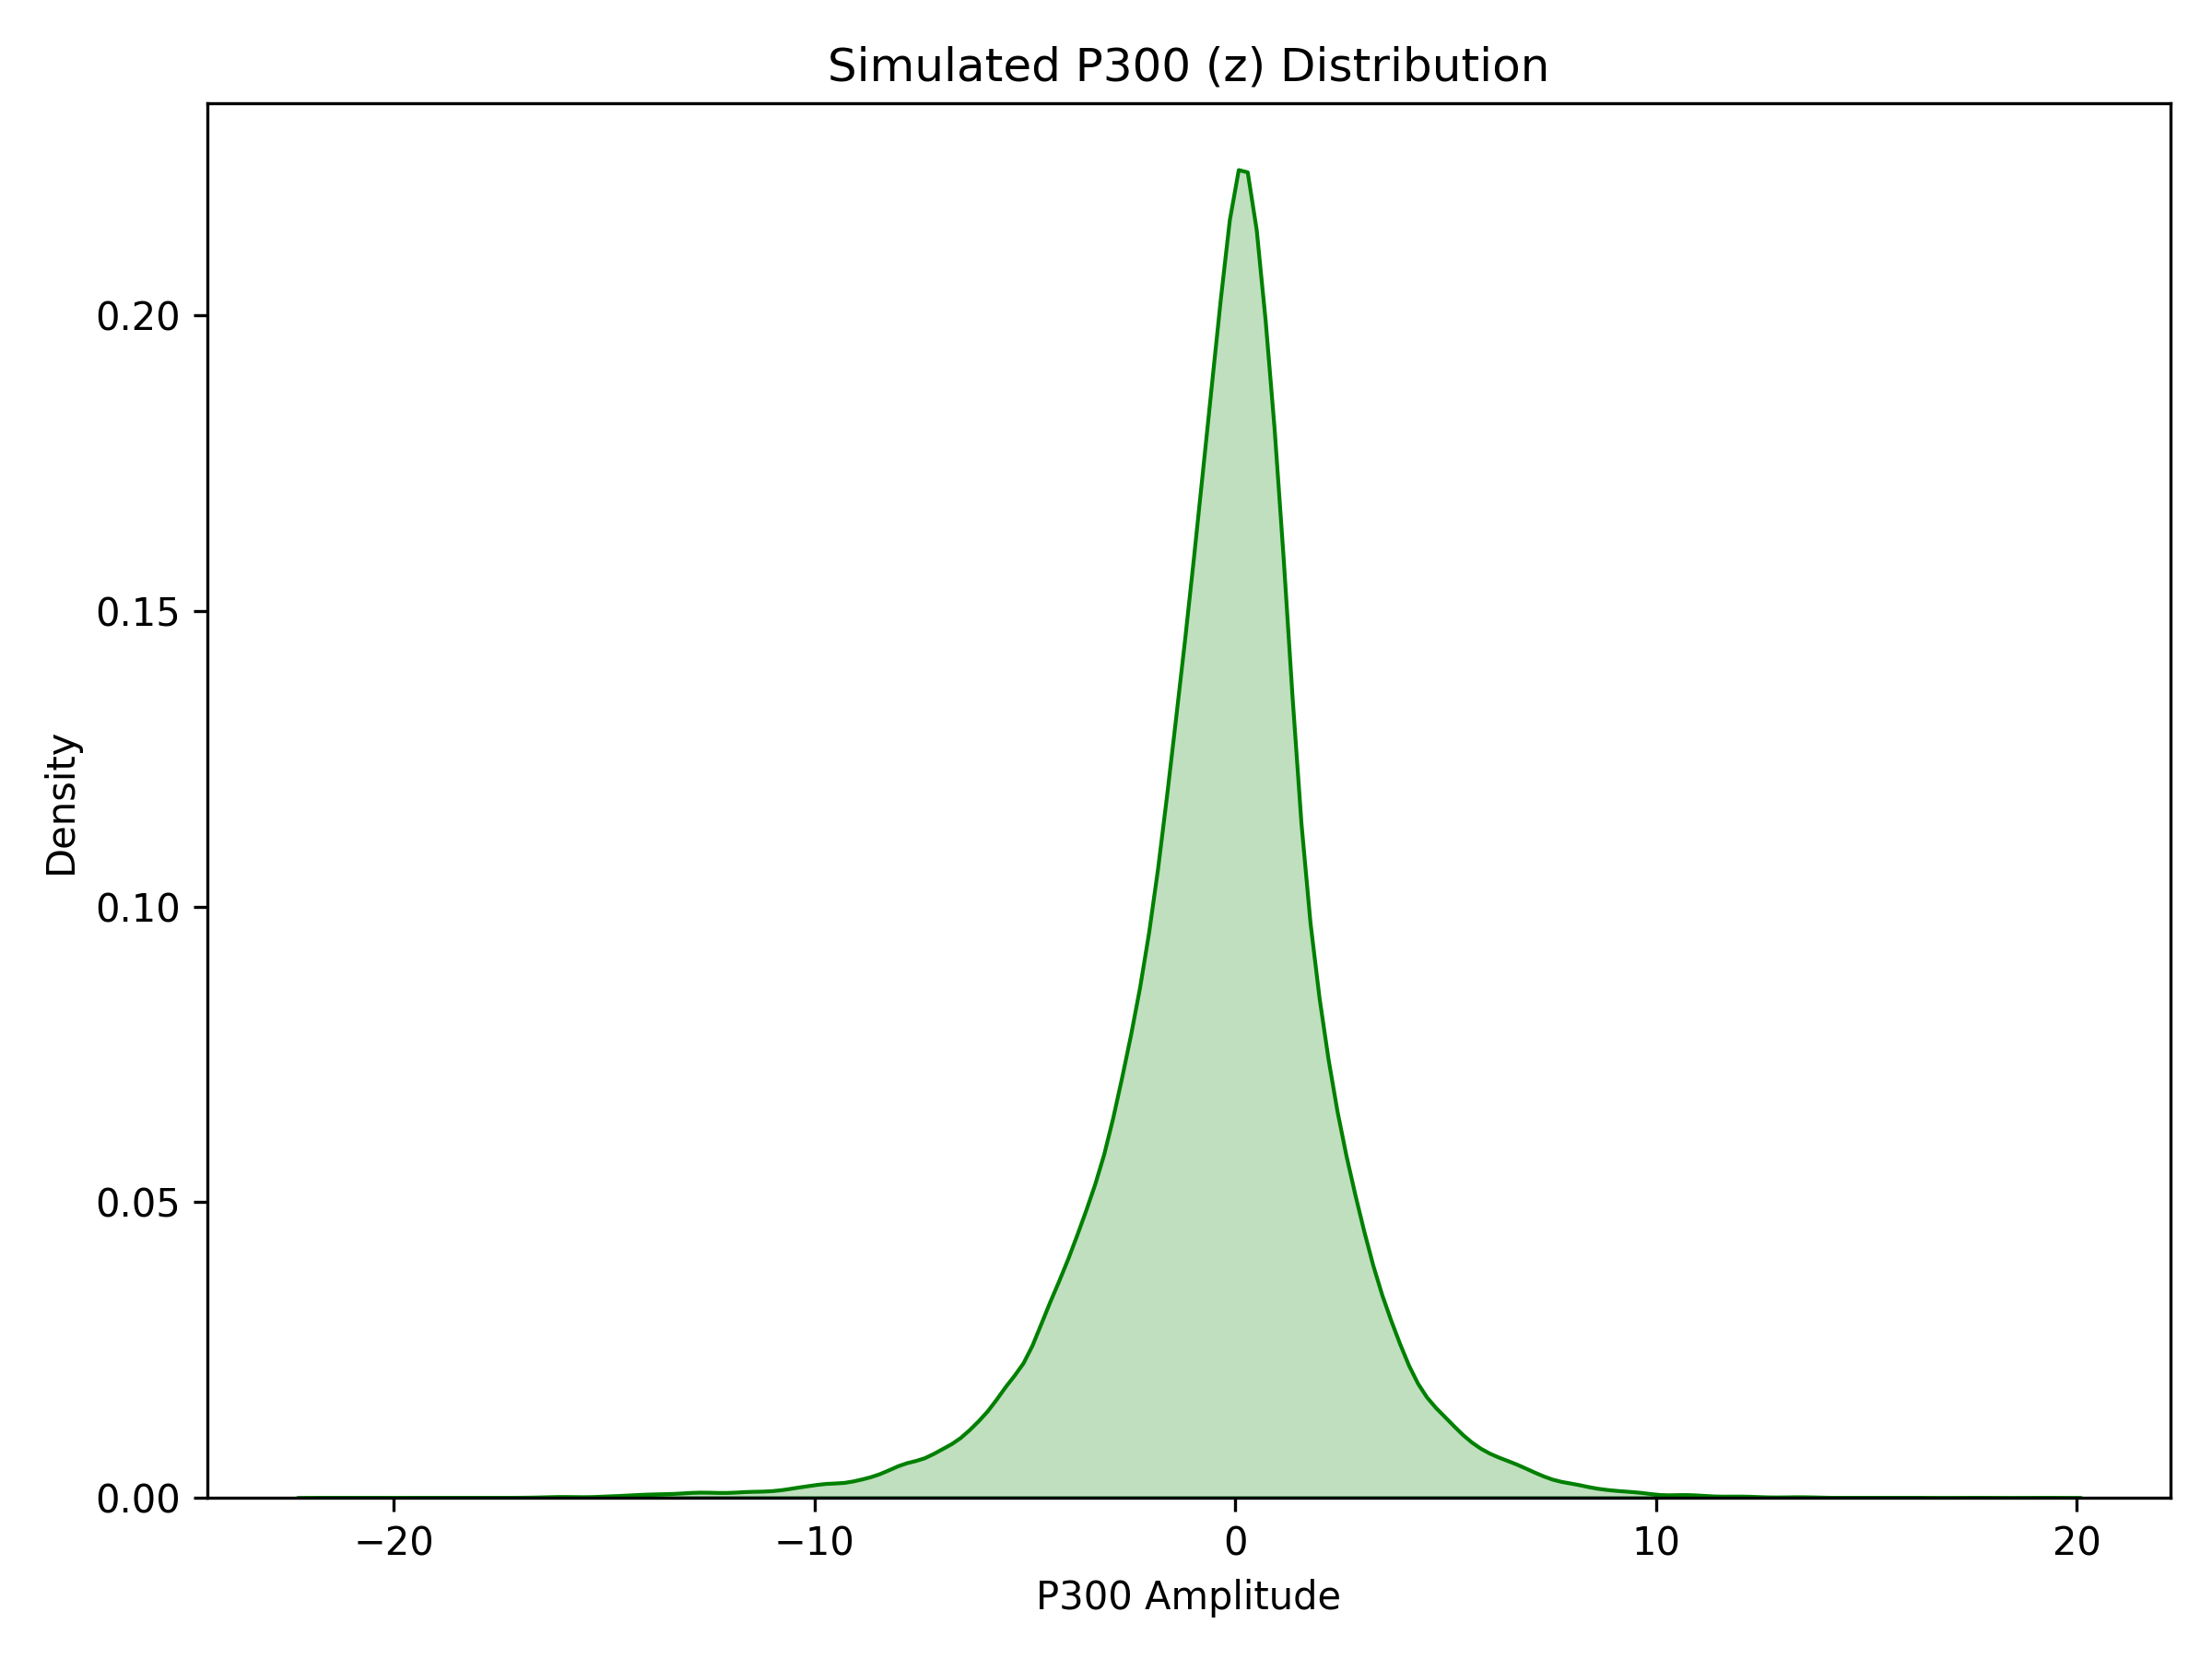

**sim_rt_distribution.png**

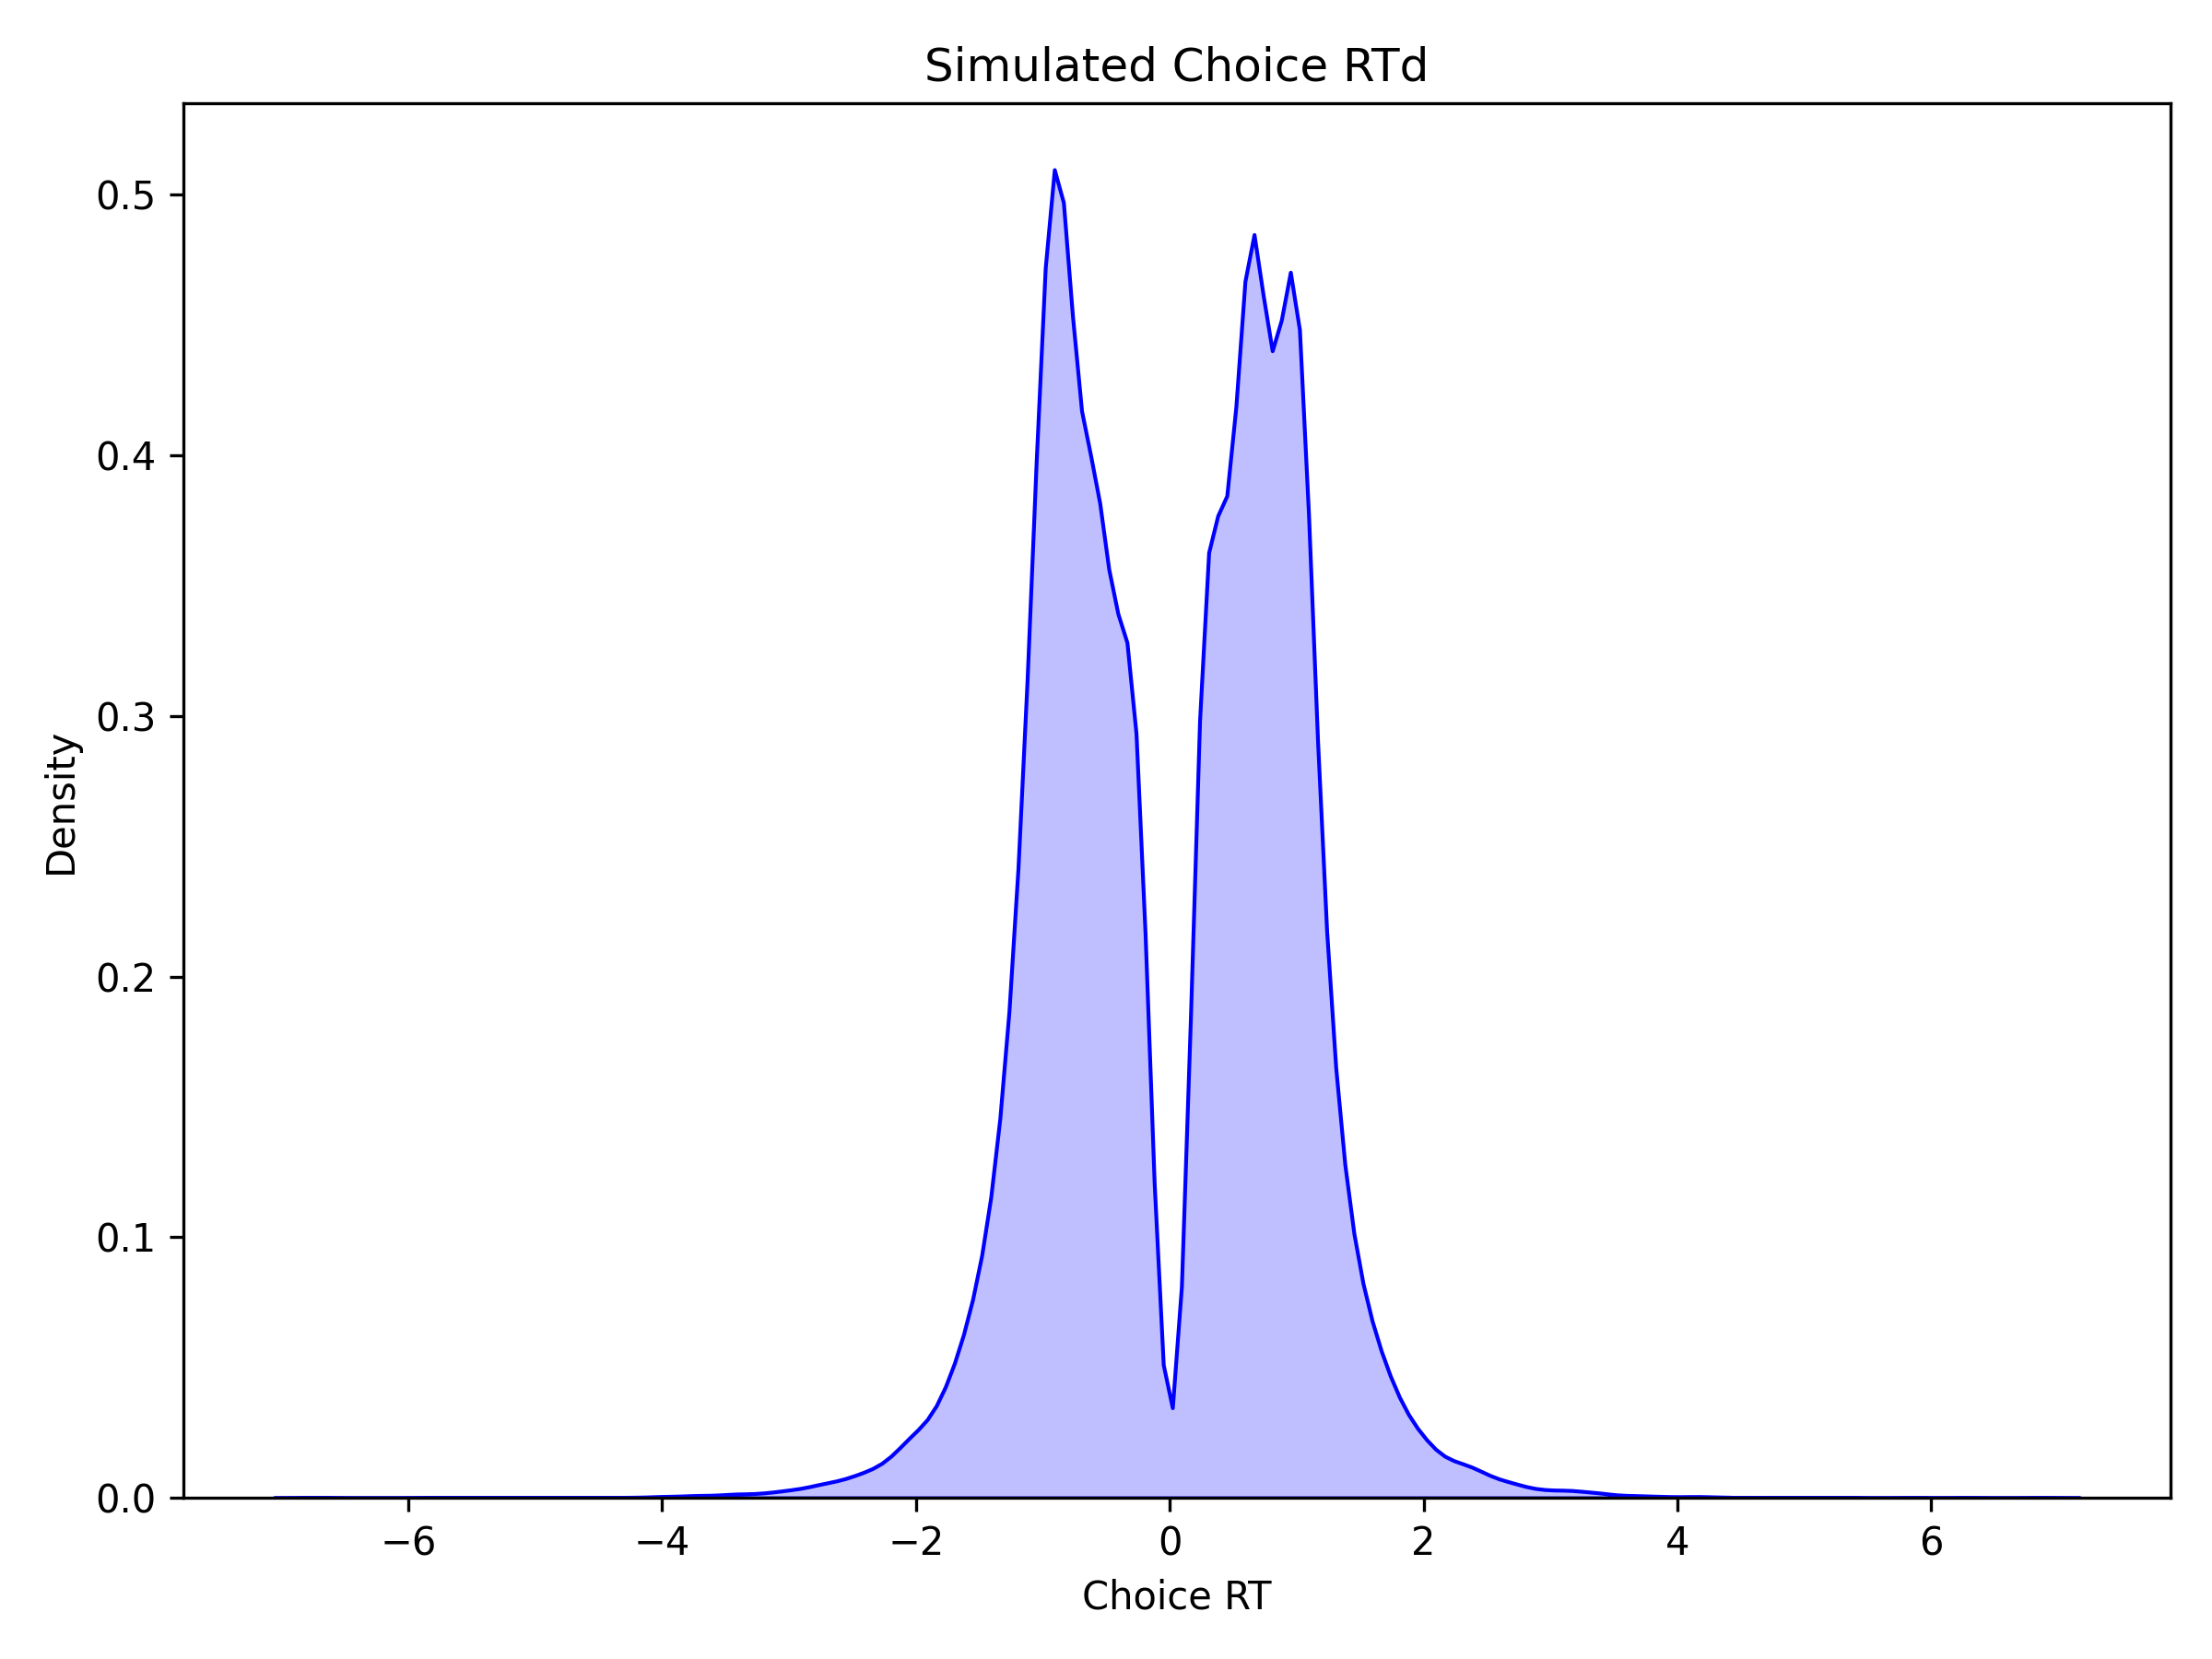

**val_P300_distribution.png**

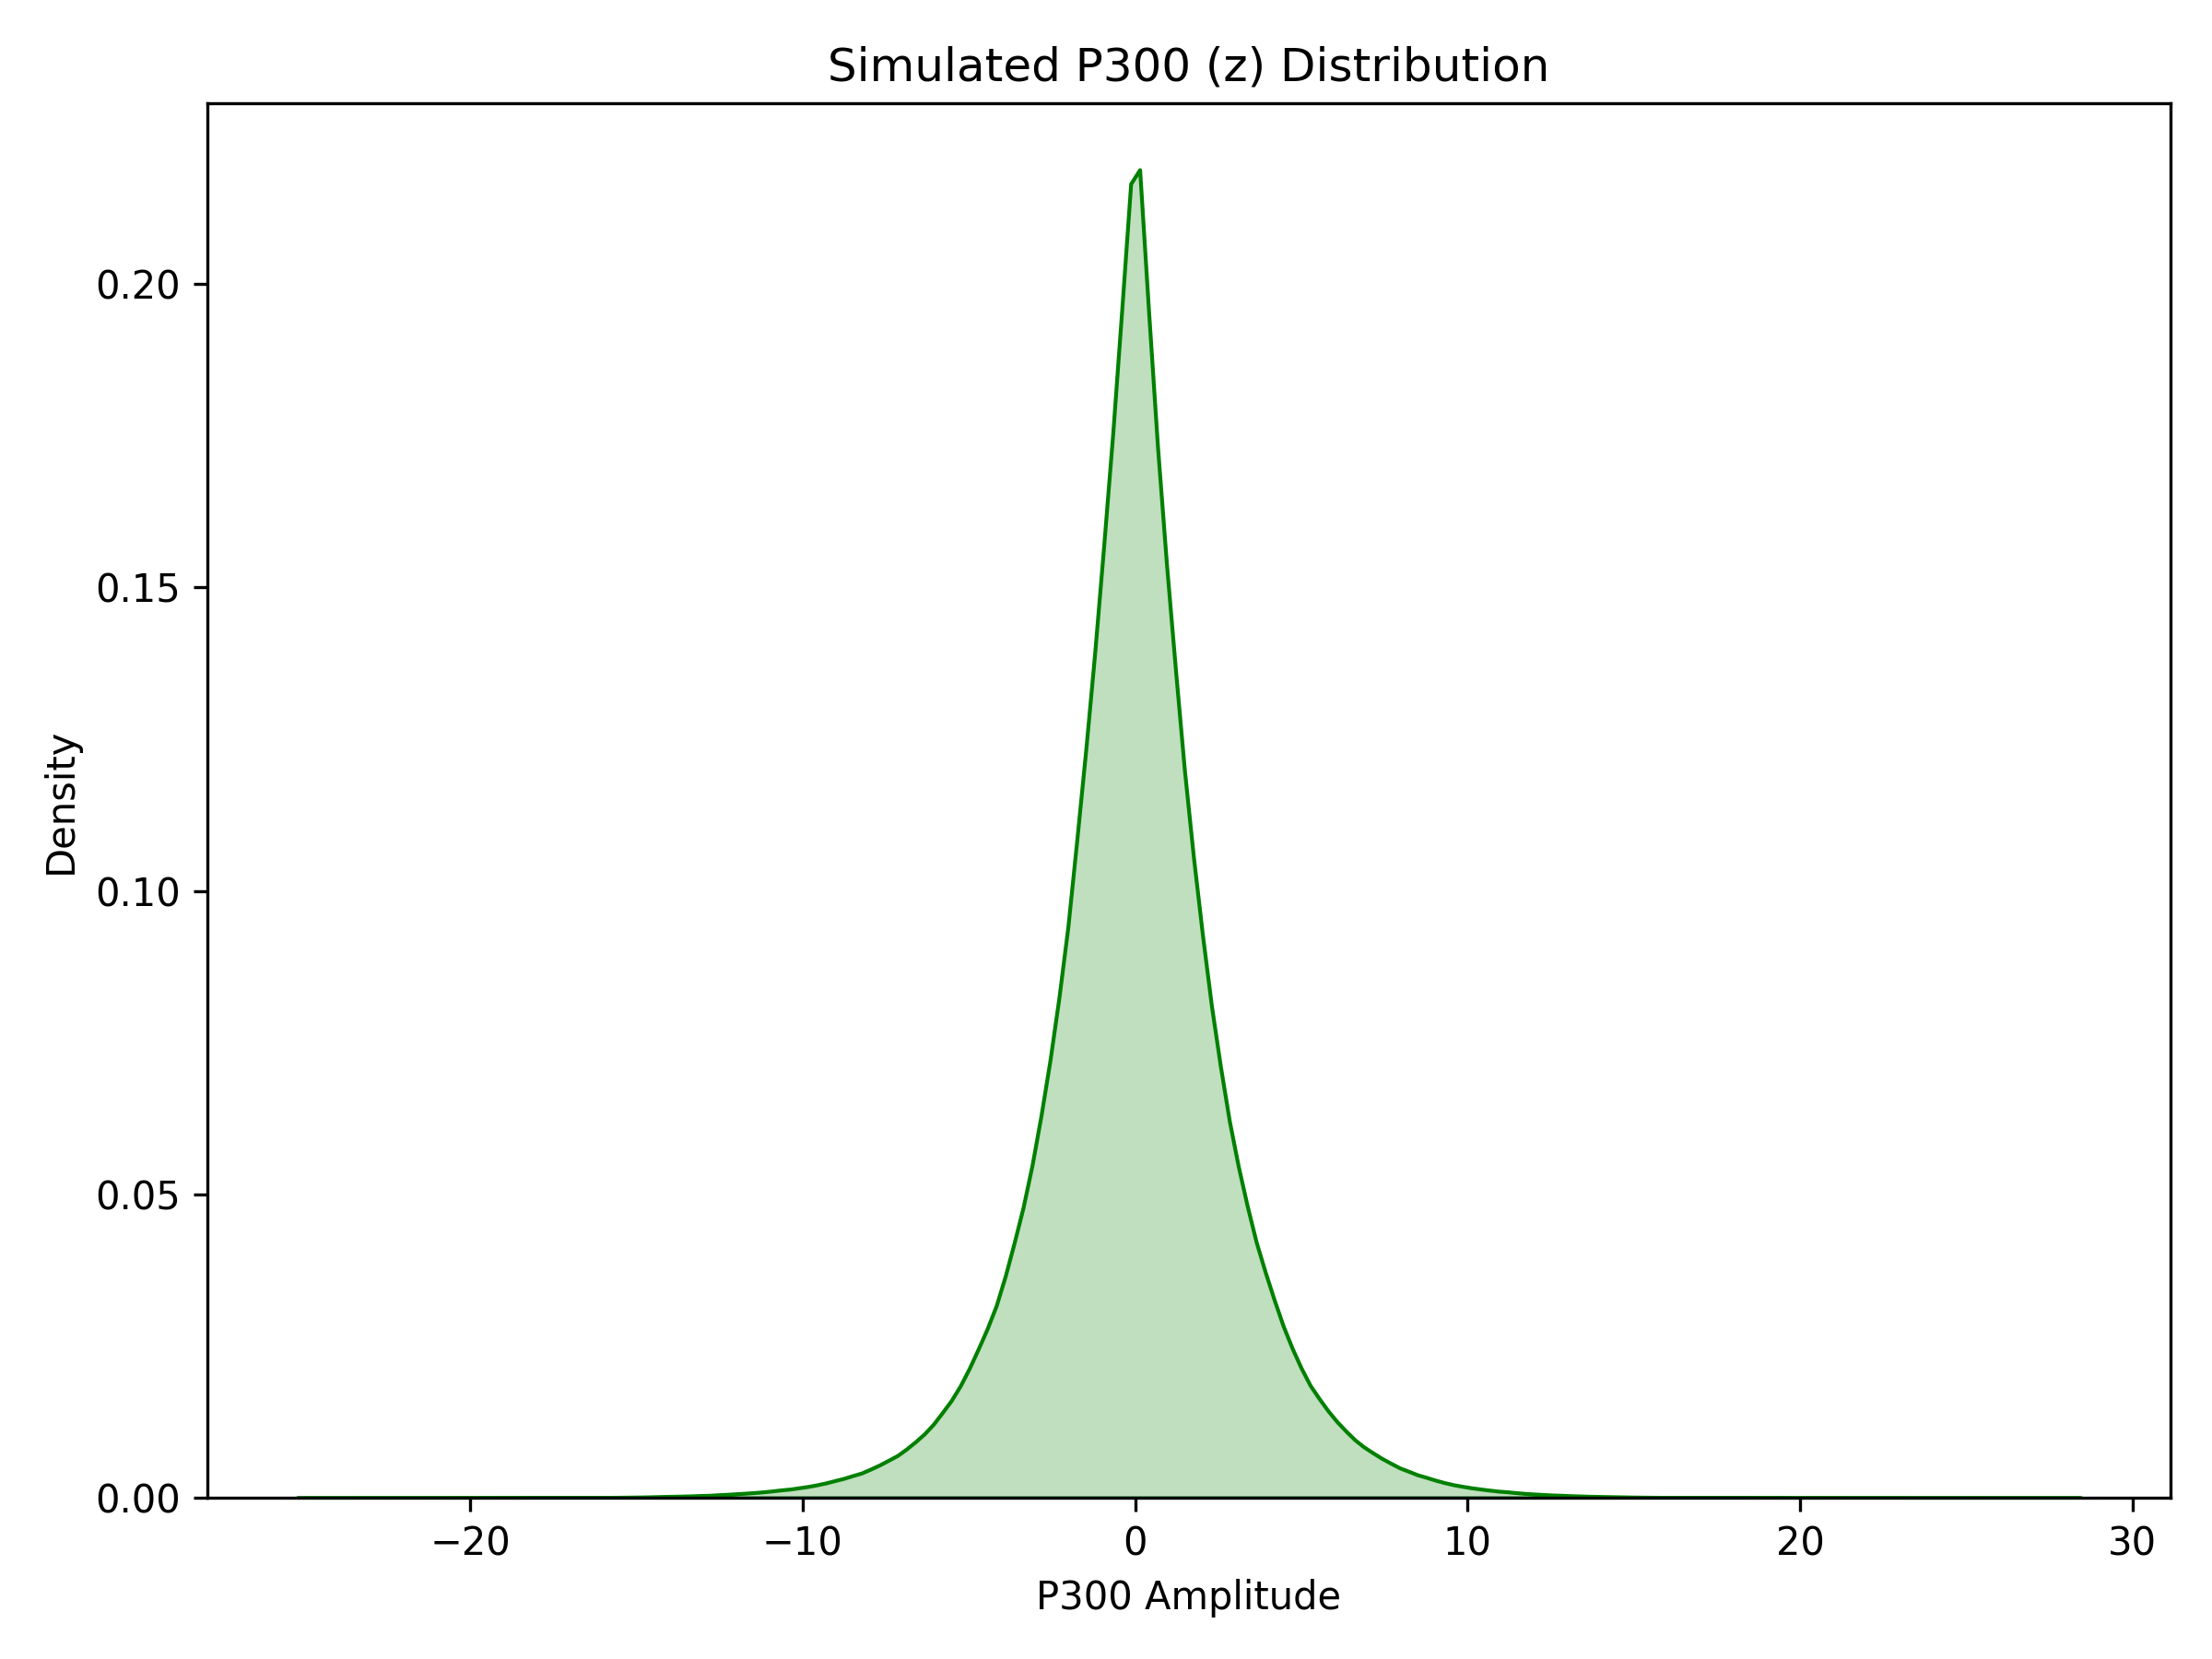

**val_rt_distribution.png**

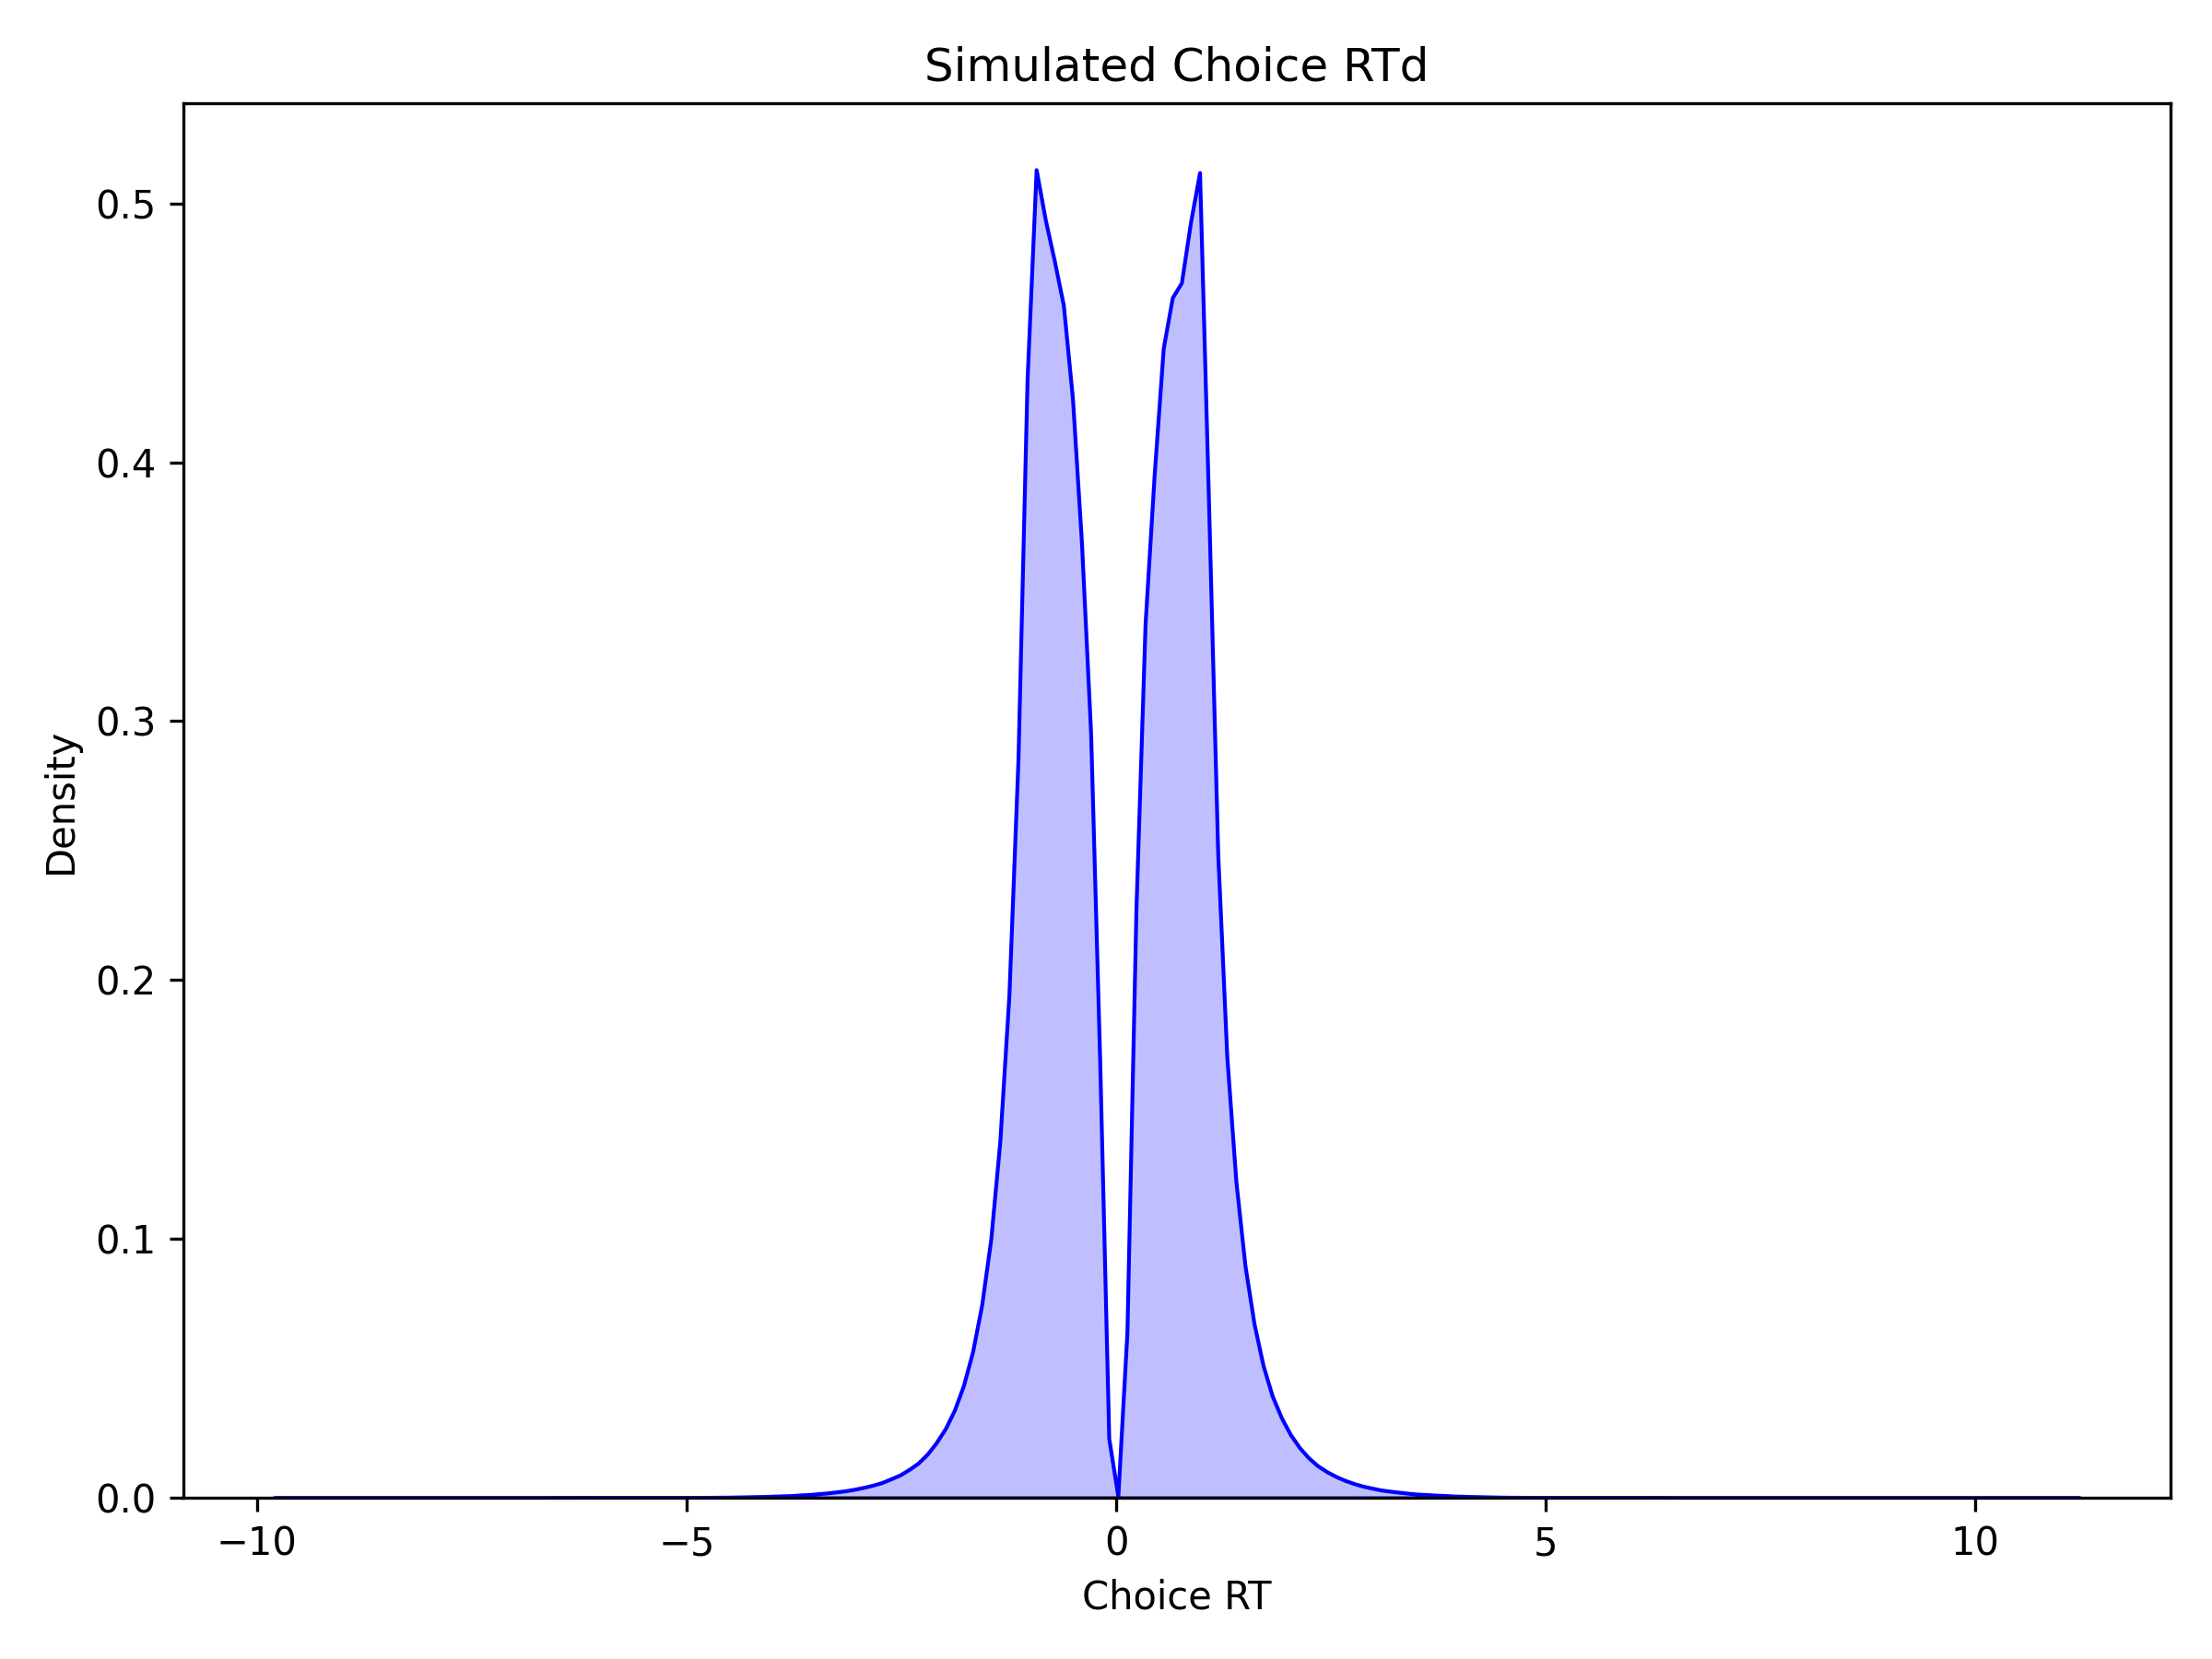

CPU times: user 52.8 ms, sys: 2.15 ms, total: 55 ms
Wall time: 70.4 ms


In [ ]:
%%time

from pathlib import Path
from IPython.display import display, Image, Markdown

MAX_PER_FOLDER = 6  # increase this number this if you want to see more plots

root = Path.cwd() / "integrative_model/Figures"
#root = Path.cwd() / "integrative_model/figures_new_sigma_new_conditions" # Uncomment for recovery plots
by_folder = {}
for p in sorted(root.rglob("*.png")):
  by_folder.setdefault(p.parent, []).append(p)

if not by_folder:
  print("No figures found yet — run the pipeline cells above first.")

for folder, pngs in by_folder.items():
  display(Markdown(f"### `{folder.relative_to(root.parent)}` — {len(pngs)} figure(s)"))
  for p in pngs[:MAX_PER_FOLDER]:
    display(Markdown(f"**{p.name}**"))
    display(Image(filename=str(p), width=760))
    if len(pngs) > MAX_PER_FOLDER:
      rest = ", ".join(p.name for p in pngs[MAX_PER_FOLDER:])
      display(Markdown(f"*...and {len(pngs) - MAX_PER_FOLDER} more: {rest}*"))
print('============================')

### Step 4.4 Evaluating the model

Read or skim [our preprint](https://osf.io/preprints/psyarxiv/7d46a_v2).

Test questions:

* What are recovery plots?
* Where are the recovery plots in your Google colab folder after running the following code? *Only run this code if you have time to wait*
* Can you use the code above to look at the recovery plots in Colab?

In [ ]:
%%time
!uv run scripts/integrative_ddm_generate_factorial_new_sigma.py
print('============================')
!uv run scripts/integrative_ddm_data_check.py
print('============================')
!uv run scripts/integrative_ddm_analyze_results_factorial.py
print('============================')